# EDA: Steam-игры

## Бизнес-цель проекта

К нам обратилась компания, занимающаяся разработкой и выпуском игр, с запросом понять, какие характеристики Steam-игры связаны с высоким интересом пользователей.

В рамках проекта мы анализируем данные по играм Steam, чтобы выявить признаки, которые чаще встречаются у более популярных игр. В качестве основной целевой переменной мы рассматриваем total_reviews - общее количество пользовательских отзывов, которое используем как показатель интереса аудитории к игре.

**Цель проекта - определить, какие особенности игры связаны с большим количеством отзывов и могут быть полезны при анализе будущих релизов**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Структура датасета


In [28]:
df = pd.read_csv('final_data.csv')
df.shape

(61191, 30)

In [29]:
df.head()

,record_type,source_file,appid,name,type,required_age,is_free,categories,platforms,genres,...,player_count,price_final,price_initial,price_currency,discount_percent,owners_lower,owners_upper,price_usd,year,playtime_median_min
0,game,merged_game_data,1313.0,SiN Gold,game,0.0,False,Single-player | Multi-player | PvP | Online Pv...,windows,Action,...,2.0,999.0,999.0,USD,0.0,100000.0,200000.0,9.99,2020.0,0.0
1,game,merged_game_data,7800.0,Stubbs the Zombie in Rebel Without a Pulse,game,17.0,False,Single-player | Multi-player | Co-op | Shared/...,windows,Action,...,8.0,1999.0,1999.0,USD,0.0,200000.0,500000.0,19.99,2021.0,0.0
2,game,merged_game_data,11550.0,Second Sight,game,0.0,False,Single-player | Family Sharing,windows,Action,...,0.0,999.0,999.0,USD,0.0,20000.0,50000.0,9.99,2021.0,0.0
3,game,merged_game_data,12210.0,Grand Theft Auto IV: The Complete Edition,game,17.0,False,Single-player | Multi-player | Partial Control...,windows,Action | Adventure,...,2507.0,1999.0,1999.0,USD,0.0,5000000.0,10000000.0,19.99,2020.0,184.0
4,game,merged_game_data,24880.0,The Saboteur™,game,17.0,False,Single-player | Family Sharing,windows,Action | Adventure,...,33.0,999.0,999.0,USD,0.0,200000.0,500000.0,9.99,2024.0,0.0


In [30]:
df.dtypes

record_type             object
source_file             object
appid                  float64
name                    object
type                    object
required_age           float64
is_free                 object
categories              object
platforms               object
genres                  object
header_image            object
short_description       object
developers              object
publishers              object
release_date            object
review_score           float64
review_score_desc       object
total_positive         float64
total_negative         float64
total_reviews          float64
player_count           float64
price_final            float64
price_initial          float64
price_currency          object
discount_percent       float64
owners_lower           float64
owners_upper           float64
price_usd              float64
year                   float64
playtime_median_min    float64
dtype: object

In [31]:
df.describe()

,appid,required_age,review_score,total_positive,total_negative,total_reviews,player_count,price_final,price_initial,discount_percent,owners_lower,owners_upper,price_usd,year,playtime_median_min
count,6.119100e+04,60942.000000,61147.000000,61147.000000,61147.000000,61147.000000,61146.000000,5.513600e+04,5.513600e+04,55136.000000,6.119100e+04,6.119100e+04,61191.000000,61191.000000,61191.000000
mean,1.893308e+06,0.435939,2.412154,299.863787,41.798518,341.662306,38.112452,1.803852e+04,1.983881e+04,4.676600,3.671700e+04,9.530519e+04,7.585716,2021.914432,11.525845
std,6.971355e+05,2.509696,3.283617,5094.969547,695.049045,5619.017918,1119.989608,6.629919e+05,7.602846e+05,16.902622,6.605550e+05,1.370548e+06,14.351234,1.701791,243.106623
min,1.313000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,7.200000e+01,0.000000,0.000000e+00,2.000000e+04,0.000000,2019.000000,0.000000
25%,1.311995e+06,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.990000e+02,2.990000e+02,0.000000,0.000000e+00,2.000000e+04,1.990000,2020.000000,0.000000
50%,1.817660e+06,0.000000,0.000000,3.000000,1.000000,4.000000,0.000000,5.990000e+02,6.590000e+02,0.000000,0.000000e+00,2.000000e+04,4.990000,2022.000000,0.000000
75%,2.438500e+06,0.000000,6.000000,16.000000,4.000000,20.000000,0.000000,1.329000e+03,1.479000e+03,0.000000,0.000000e+00,2.000000e+04,9.990000,2023.000000,0.000000
max,3.595270e+06,21.000000,9.000000,508616.000000,107395.000000,616011.000000,200612.000000,7.900000e+07,8.790000e+07,100.000000,1.000000e+08,2.000000e+08,1000.000000,2024.000000,20052.000000


Итого ~61k строк и 30 столбцов. Целевая переменная - total_reviews

## Пропуски


In [32]:
miss = df.isnull().sum()
miss_pct = miss / len(df) * 100
missing_df = pd.DataFrame({'count': miss, 'pct': miss_pct}).sort_values('pct', ascending=False)
missing_df = missing_df[missing_df['count'] > 0]
print(missing_df)

                   count       pct
discount_percent    6055  9.895246
price_currency      6055  9.895246
price_initial       6055  9.895246
price_final         6055  9.895246
publishers           475  0.776258
developers           311  0.508245
genres               292  0.477194
header_image         281  0.459218
short_description    271  0.442876
categories           253  0.413459
is_free              249  0.406923
platforms            249  0.406923
required_age         249  0.406923
release_date         249  0.406923
type                 249  0.406923
player_count          45  0.073540
total_reviews         44  0.071906
name                  44  0.071906
review_score          44  0.071906
total_negative        44  0.071906
total_positive        44  0.071906
review_score_desc     44  0.071906


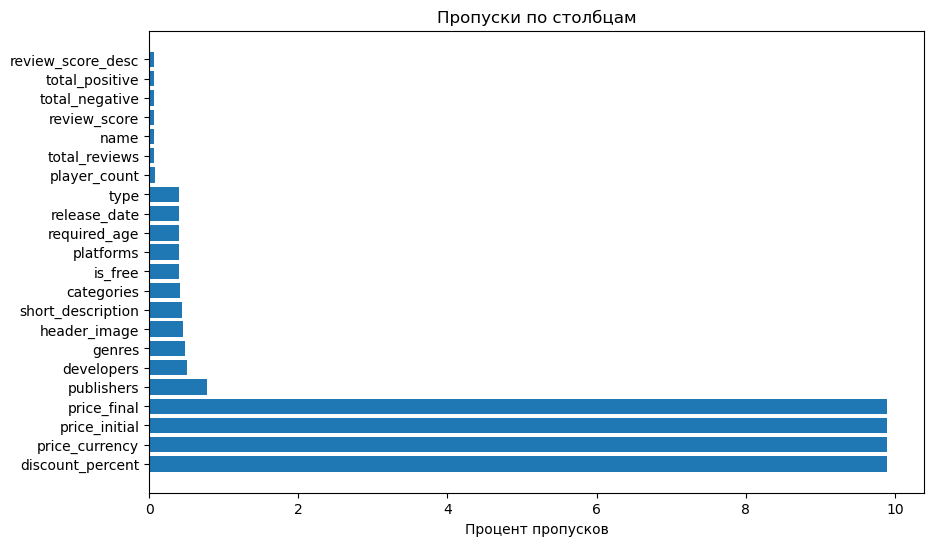

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(missing_df.index, missing_df['pct'])
plt.xlabel('Процент пропусков')
plt.title('Пропуски по столбцам')
plt.show()

Как заполняем пропуски

- discount_percent заполняем 0, так как пропущенное значение означает, что скидки нет
- required_age и player_count заполняем 0, т.к. нулевое значение для них не повляет на анализ сильно
- total_positive, total_negative заполняем 0, а total_reviews - по сумме положительных и отрицательных отзывов, если это невозможно, то 0
- publishers, developers, genres, categories, platforms, type, name, review_score_desc заполняем Unknown, чтобы сохранить строковые значения
- header_image и short_description заполняем значениями No image и No description
- price_final и price_initial для бесплатных игр заполняем 0, а в остальных случаях заполняем столбец значением другого, если оно известно
- price_currency заполняем Unknown
- review_score заполняем 0, если нет отзывов, а оставшиеся пропуски заполняем медианой
- is_free считаем бесплатной, если price_final = 0, а если price_final > 0, то платной
- release_date переводим в формат даты принудительно

In [ ]:
df['discount_percent'] = df['discount_percent'].fillna(0)
df['required_age'] = df['required_age'].fillna(0)
df['player_count'] = df['player_count'].fillna(0)
df['total_positive'] = df['total_positive'].fillna(0)
df['total_negative'] = df['total_negative'].fillna(0)
df['total_reviews'] = df['total_reviews'].fillna(df['total_positive'] + df['total_negative'])
df['total_reviews'] = df['total_reviews'].fillna(0)
df['publishers'] = df['publishers'].fillna('Unknown')
df['developers'] = df['developers'].fillna('Unknown')
df['genres'] = df['genres'].fillna('Unknown')
df['categories'] = df['categories'].fillna('Unknown')
df['platforms'] = df['platforms'].fillna('Unknown')
df['type'] = df['type'].fillna('Unknown')
df['name'] = df['name'].fillna('Unknown')
df['header_image'] = df['header_image'].fillna('No image')
df['short_description'] = df['short_description'].fillna('No description')
df['review_score_desc'] = df['review_score_desc'].fillna('Unknown')
df.loc[df['is_free'] == True, 'price_final'] = df.loc[df['is_free'] == True, 'price_final'].fillna(0)
df.loc[df['is_free'] == True, 'price_initial'] = df.loc[df['is_free'] == True, 'price_initial'].fillna(0)
df['price_final'] = df['price_final'].fillna(df['price_initial'])
df['price_initial'] = df['price_initial'].fillna(df['price_final'])
df['price_currency'] = df['price_currency'].fillna('Unknown')
df.loc[df['total_reviews'] == 0, 'review_score'] = df.loc[df['total_reviews'] == 0, 'review_score'].fillna(0)
df['review_score'] = df['review_score'].fillna(df['review_score'].median())
df.loc[df['is_free'].isna() & (df['price_final'] == 0), 'is_free'] = True
df.loc[df['is_free'].isna() & (df['price_final'] > 0), 'is_free'] = False

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
print(df.isnull().sum()[df.isnull().sum() > 0])

is_free            249
release_date     34280
price_final        355
price_initial      355
dtype: int64


##  Проверка аномалий


In [35]:
neg_price = df[df['price_final'] < 0]
print('Отрицательная price_final:', len(neg_price))

Отрицательная price_final: 0


In [36]:
bad_disc = df[df['discount_percent'] > 100]
print('Скидка больше 100%:', len(bad_disc))

Скидка больше 100%: 0


In [37]:
neg_players = df.query('player_count < 0')
print('Отрицательный player_count:', len(neg_players))

Отрицательный player_count: 0


In [38]:
bad_owners = df[df['owners_lower'] > df['owners_upper']]
print('owners_lower > owners_upper:', len(bad_owners))

owners_lower > owners_upper: 0


In [58]:
print('Значения required_age:')
print(df['required_age'].value_counts().head(15))

Значения required_age:
required_age
0.0     59325
14.0      465
18.0      425
10.0      385
12.0      184
16.0      177
17.0      157
13.0       50
7.0         7
15.0        5
3.0         5
6.0         2
21.0        1
20.0        1
5.0         1
Name: count, dtype: int64


In [40]:
weird_age = df[df['required_age'] > 21]
print('Строк с required_age > 21:', len(weird_age))

Строк с required_age > 21: 0


Данные в целом чистые. Есть нестандартные значения required_age (и нет более 21+), но для нашего анализа это некритично

## Распределение total_reviews

In [61]:
print('Стата по total_reviews:')
print(df['total_reviews'].describe())

Стата по total_reviews:
count     61191.000000
mean        341.416630
std        5617.004783
min           0.000000
25%           1.000000
50%           4.000000
75%          20.000000
max      616011.000000
Name: total_reviews, dtype: float64


In [62]:
print('Квантили total_reviews:')
print(df['total_reviews'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('total_reviews'))

Квантили total_reviews:
      total_reviews
0.50            4.0
0.75           20.0
0.90          121.0
0.95          444.5
0.99         4893.5


In [63]:
print('Доля игр с колвом отзывов меньше 100:')
print((df['total_reviews'] < 100).mean() * 100)

Доля игр с колвом отзывов меньше 100:
88.94608684283637


In [64]:
print('Топ10 игр по колву отзывов:')
print(df[['appid', 'name', 'total_reviews']].sort_values('total_reviews', ascending=False).head(10))

Топ10 игр по колву отзывов:
           appid                   name  total_reviews
546     553850.0          HELLDIVERS™ 2       616011.0
7420   1086940.0        Baldur's Gate 3       438345.0
13013  1245620.0             ELDEN RING       424955.0
7573   1091500.0         Cyberpunk 2077       370424.0
1461    739630.0           Phasmophobia       348873.0
10583  1174180.0  Red Dead Redemption 2       292432.0
34641  1966720.0         Lethal Company       273603.0
2712    892970.0                Valheim       253968.0
8533   1118200.0      People Playground       171960.0
526     548430.0     Deep Rock Galactic       168837.0


total_reviews распределён неравномерно: у большинства игр отзывов очень мало, а небольшая группа проектов сильно выделяется по этому принзаку. Это видно по тому, что медиана равна 4, а среднее - более 340, то есть распределение сильно скошено вправо. Квантили тоже подтверждают это: 75% игр имеют не более 20 отзывов, а почти 89% игр - меньше 100 отзывов. При этом в выборке есть отдельные игры с сотнями тысяч отзывов. Значит, total_reviews хорошо отражает неравномерность пользовательского интереса на Steam и мы можем юзать ее как целевую переменную для дальнейшего анализа

## Выбросы в total_reviews

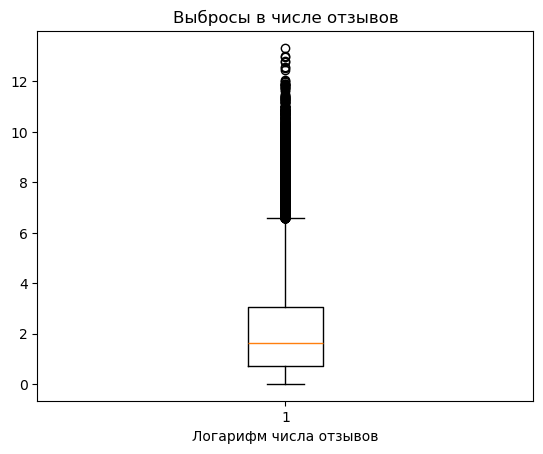

In [65]:
log_reviews = np.log1p(df['total_reviews'].dropna())

plt.boxplot(log_reviews)
plt.xlabel('Логарифм числа отзывов')
plt.title('Выбросы в числе отзывов')
plt.show()

В total_reviews виден заметный правый хвост и большое количество выбросов. Это означает, что рынок Steam по пользовательскому интересу остаётся сильно неоднородным. У большинства игр отзывов немного, а небольшая группа проектов резко выделяется по этому признаку

## Структура отзывов

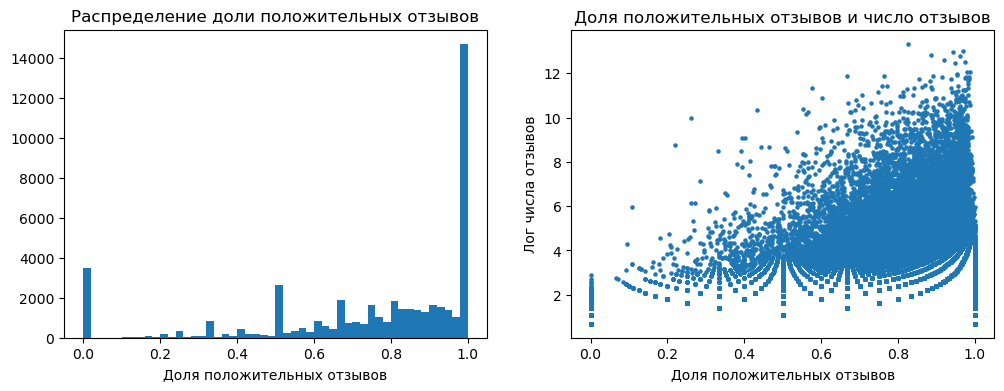

In [73]:
df['positive_ratio'] = np.where(df['total_reviews'] > 0, df['total_positive'] / df['total_reviews'], np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['positive_ratio'].dropna(), bins=50)
axes[0].set_title('Распределение доли положительных отзывов')
axes[0].set_xlabel('Доля положительных отзывов')
axes[1].scatter(df['positive_ratio'], np.log1p(df['total_reviews']), s=5)
axes[1].set_title('Доля положительных отзывов и число отзывов')
axes[1].set_xlabel('Доля положительных отзывов')
axes[1].set_ylabel('Лог числа отзывов')
plt.show()

По распределению positive_ratio видно, что у большинства игр доля положительных отзывов достаточно высокая. На графике зависимости также заметно, что игры с большим числом отзывов чаще встречаются при высоких значениях доли положительных отзывов. Можно предположить, что высокий интерес аудитории нередко сочетается с положительными эмоциями от игры пользователями

## Корр матрица

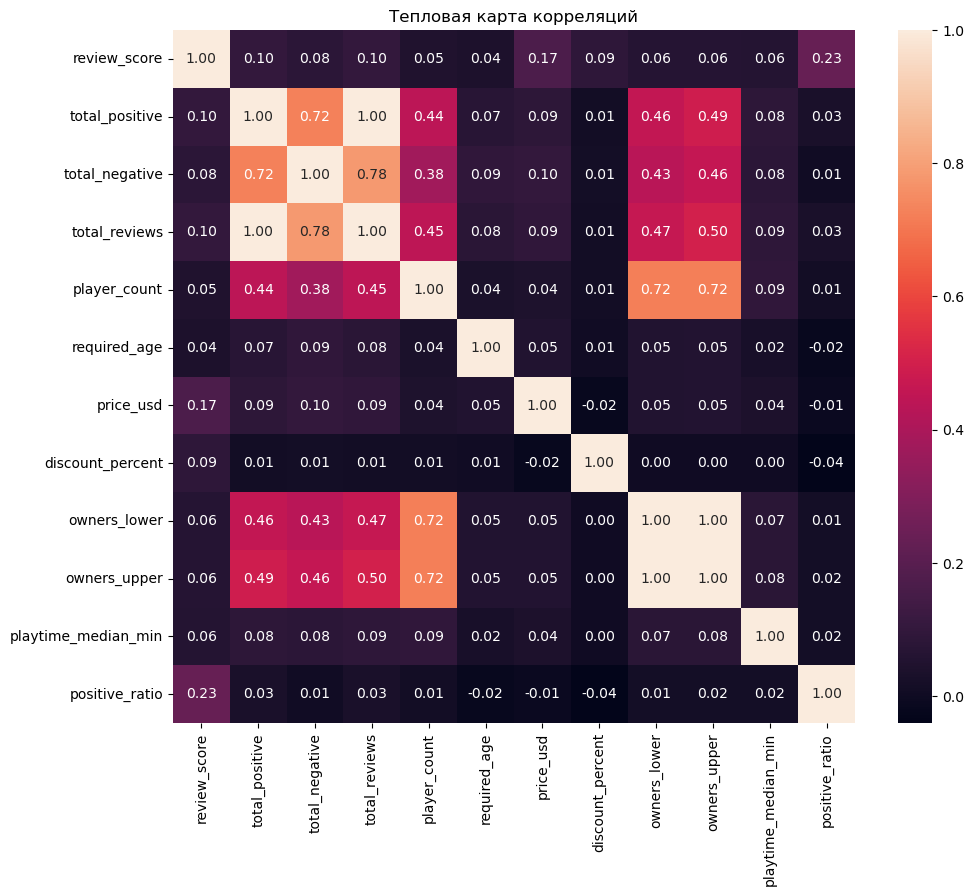

In [74]:
cols = ['review_score', 'total_positive', 'total_negative', 'total_reviews', 'player_count', 'required_age', 'price_usd', 'discount_percent', 'owners_lower', 'owners_upper', 'playtime_median_min', 'positive_ratio']

plt.figure(figsize=(11, 9))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f')
plt.title('Тепловая карта корреляций')
plt.show()

total_reviews сильнее всего коррелирует с owners_upper (0.5) и player_count (0.45).С playtime_median_min связь слабее (0.1)

### Распределение player_count

In [79]:
print('Описательная статистика по player_count:')
print(df['player_count'].describe())

Описательная статистика по player_count:
count     61191.000000
mean         38.084424
std        1119.578181
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      200612.000000
Name: player_count, dtype: float64


In [80]:
print('Квантили player_count:')
print(df['player_count'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('player_count'))

Квантили player_count:
      player_count
0.50           0.0
0.75           0.0
0.90           2.0
0.95          10.0
0.99         251.0


In [81]:
print('Доля игр c player_count меньше 10:')
print((df['player_count'] < 10).mean() * 100)

Доля игр c player_count меньше 10:
94.8570868264941


In [82]:
print('Топ10 игр по player_count:')
print(df[['appid', 'name', 'player_count']].sort_values('player_count', ascending=False).head(10))

Топ10 игр по player_count:
           appid                    name  player_count
10519  1172470.0           Apex Legends™      200612.0
44002  2357570.0              Overwatch®       60194.0
52594  2767030.0           Marvel Rivals       50616.0
11592  1203220.0      NARAKA: BLADEPOINT       49310.0
10583  1174180.0   Red Dead Redemption 2       45480.0
546     553850.0           HELLDIVERS™ 2       43800.0
7420   1086940.0         Baldur's Gate 3       43217.0
25211  1623730.0                Palworld       40448.0
13013  1245620.0              ELDEN RING       38173.0
45013  2399830.0  ARK: Survival Ascended       34642.0


Показатель player_count распределён неравномерно. У большинства игр текущий онлайн невысокий, а заметно высокая активность наблюдается только у небольшой части buh. Это означает, что активная аудитория на Steam концентрируется у ограниченного пула игр, тогда как основная масса игр имеет небольшой текущий онлайн

### Распределение owners_upper

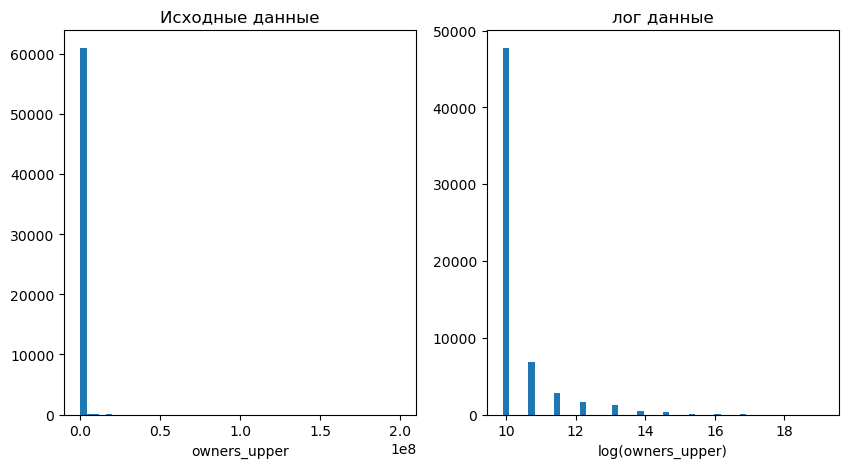

In [83]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(df['owners_upper'], bins=50)
plt.xlabel('owners_upper')
plt.title('Исходные данные')
plt.subplot(1, 2, 2)
plt.hist(np.log(df['owners_upper']), bins=50)
plt.xlabel('log(owners_upper)')
plt.title('лог данные')
plt.show()

Ступеньки на сырой гистограмме - это особенности данных из SteamSpy, где количество владельцев идёт когротами. После логарифмирования распределение становится более гладким и интерпретируемым

### Анализ зависимости owners_upper и total_reviews

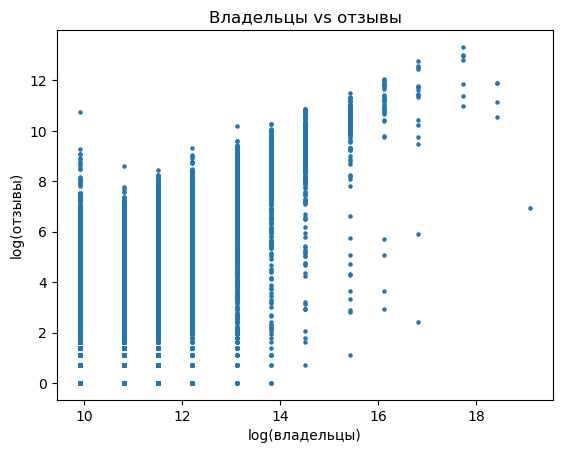

In [85]:
clean = df[(df['owners_upper'] > 0) & (df['total_reviews'] > 0)]

plt.scatter(np.log(clean['owners_upper']), np.log(clean['total_reviews']), s=5)
plt.xlabel('log(владельцы)')
plt.ylabel('log(отзывы)')
plt.title('Владельцы vs отзывы')
plt.show()

Корреляция между владельцами и отзывами в лог пространстве == 0.5. Это положительная связь: в целом игры с большим числом владельцев собирают больше отзывов, но зависимость не идеальная. Разброс на графике это подтверждает - много точек отклоняется от основной линии

### Распределение playtime_median_min

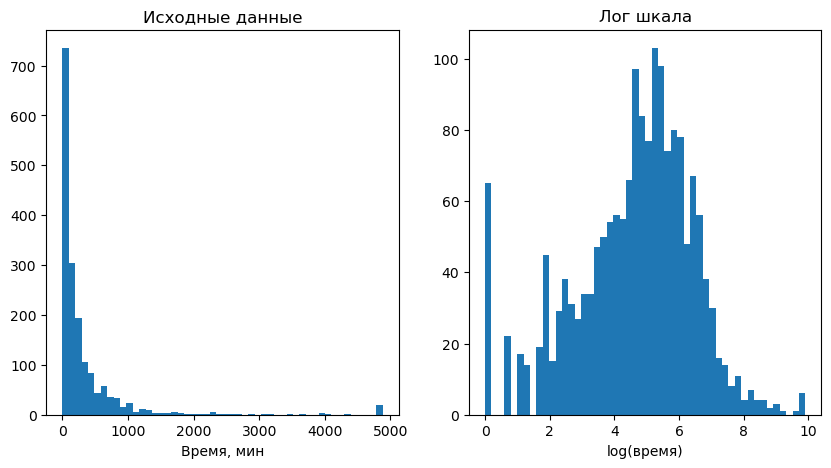

In [87]:
pt = df[df['playtime_median_min'] > 0]['playtime_median_min']

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(pt.clip(upper=pt.quantile(0.99)), bins=50)
plt.xlabel('Время, мин')
plt.title('Исходные данные')
plt.subplot(1, 2, 2)
plt.hist(np.log(pt), bins=50)
plt.xlabel('log(время)')
plt.title('Лог шкала')
plt.show()

Медианное время игры сильно различается. В большинство игр играют короче по врепмени, но есть длинный хвост игр с сотнями часов. Видим лог-норм распределение

### Анализ зависимости playtime_median_min и total_reviews

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


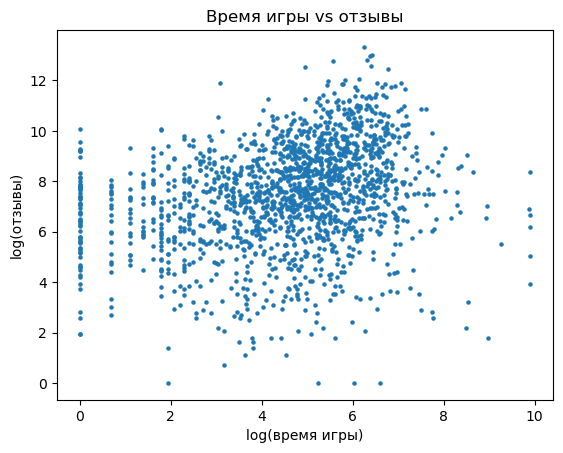

In [88]:
tmp = df[df['playtime_median_min'] > 0]

plt.scatter(np.log(tmp['playtime_median_min']), np.log(tmp['total_reviews']), s=5)
plt.xlabel('log(время игры)')
plt.ylabel('log(отзывы)')
plt.title('Время игры vs отзывы')
plt.show()

Слабая положительная корреляция (0.1). В игры, в которые играют дольше, обычно пишут немного больше отзывов, но связь очень слабая. Вовлечённость аудитории связана с количеством отзывов, но не сильно

## Анализ признаков для создания игры с большим интересом пользователей

Категории и жанры были вида Action | RPG | ... и т.п., поэтому мы решили закодировать их с помощью OHE (берем 15 популярных категорий и 10 популярных жанров)

### Топ жанров по числу отзывов

In [90]:
from collections import Counter # https://docs.python.org/3/library/collections.html#collections.Counter

g_counter = Counter()
for row in df['genres'].dropna():
    for g in str(row).split(' | '):
        g_counter[g.strip()] += 1
top_genres = [g for g, i in g_counter.most_common(15)]
for g in top_genres:
    col = 'genre_' + g.lower().replace(' ','_').replace('&','and')
    df[col] = df['genres'].str.contains(g, na=False)
df[[col for col in df.columns if col.startswith('genre_')]].sum().sort_values(ascending=False)

genre_indie                    44169
genre_casual                   27665
genre_adventure                25375
genre_action                   25239
genre_simulation               12911
genre_strategy                 11896
genre_rpg                      11688
genre_early_access              5833
genre_free_to_play              3787
genre_sports                    2581
genre_racing                    2242
genre_massively_multiplayer     1114
genre_unknown                    292
genre_game_development            17
genre_education                   15
dtype: int64

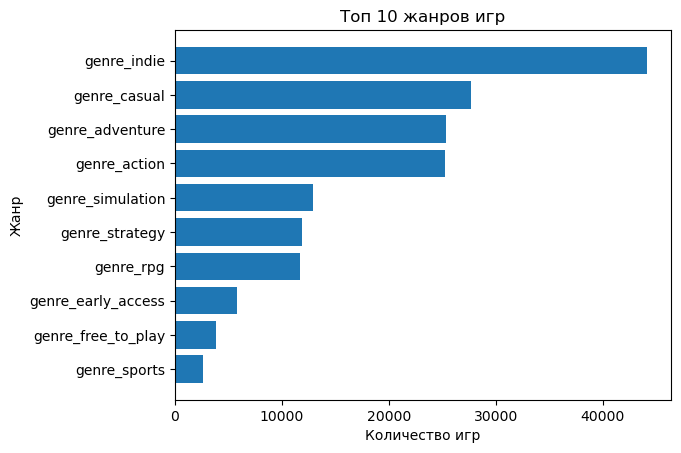

In [91]:
genre_sums = df[[col for col in df.columns if col.startswith('genre_')]].sum().sort_values(ascending=False)
top_15_genre_sums = genre_sums.head(10)

plt.barh(top_15_genre_sums.index[::-1], top_15_genre_sums.values[::-1])
plt.xlabel('Количество игр')
plt.ylabel('Жанр')
plt.title('Топ 10 жанров игр')
plt.show()

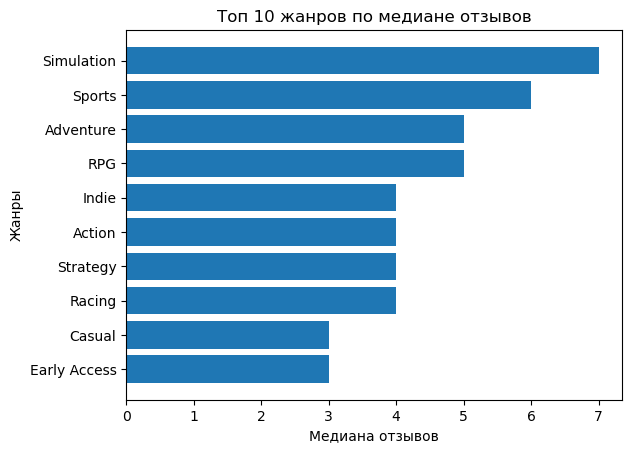

In [92]:
genre_reviews_data = []
for genre in top_genres:
    col = 'genre_' + genre.lower().replace(' ','_').replace('&','and')
    reviews = df[df[col] == True]['total_reviews']
    if len(reviews) > 0:
        genre_reviews_data.append({'genre': genre,'median_reviews': reviews.median(),'count': len(reviews)})
genre_reviews_df = pd.DataFrame(genre_reviews_data)
top_genres_median = genre_reviews_df.set_index('genre')['median_reviews'].sort_values(ascending=False).head(10)

plt.barh(top_genres_median.index[::-1], top_genres_median.values[::-1])
plt.xlabel('Медиана отзывов')
plt.ylabel('Жанры')
plt.title('Топ 10 жанров по медиане отзывов')
plt.show()

Самые успешные категории по числу отзывов - Simulation, RPG и Sports

### Топ категорий по числу отзывов

In [93]:
cats_useless = {'Family Sharing', 'Steam Achievements','Steam Cloud','Steam Trading Cards','Steam Leaders'}
cats_counter = Counter()
for row in df['categories'].dropna():
    cats_counter.update(set(str(row).split(' | '))-cats_useless)
top_cats = [cat for cat, _ in cats_counter.most_common(15)]
for cat in top_cats:
    col = f"cat_{cat.lower().replace(' ', '_').replace('/', '_')}"
    df[col] = df['categories'].str.contains(cat, na=False, regex=False)
df[[col for col in df.columns if col.startswith('cat_')]].sum().sort_values(ascending=False)

cat_single-player                 58926
cat_full_controller_support       13856
cat_multi-player                   9883
cat_partial_controller_support     7436
cat_pvp                            6475
cat_co-op                          5718
cat_online_pvp                     4385
cat_steam_leaderboards             4308
cat_shared_split_screen            4265
cat_remote_play_together           3983
cat_online_co-op                   3531
cat_shared_split_screen_pvp        2780
cat_tracked_controller_support     2637
cat_vr_only                        2598
cat_shared_split_screen_co-op      2479
dtype: int64

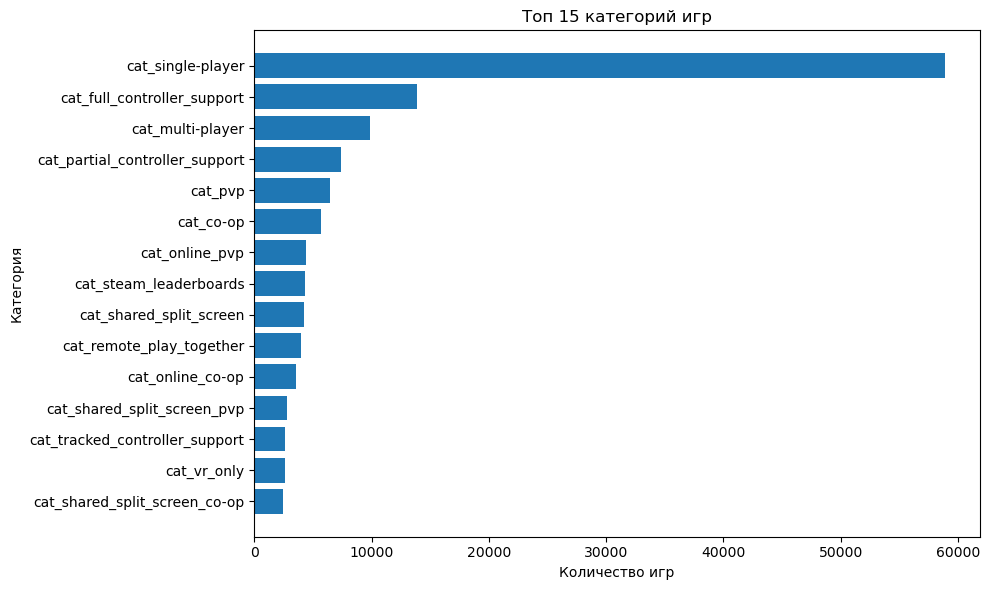

In [94]:
cat_sums = df[[col for col in df.columns if col.startswith('cat_')]].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(cat_sums.index[::-1], cat_sums.values[::-1])
plt.xlabel('Количество игр')
plt.ylabel('Категория')
plt.title('Топ 15 категорий игр')
plt.tight_layout()
plt.show()

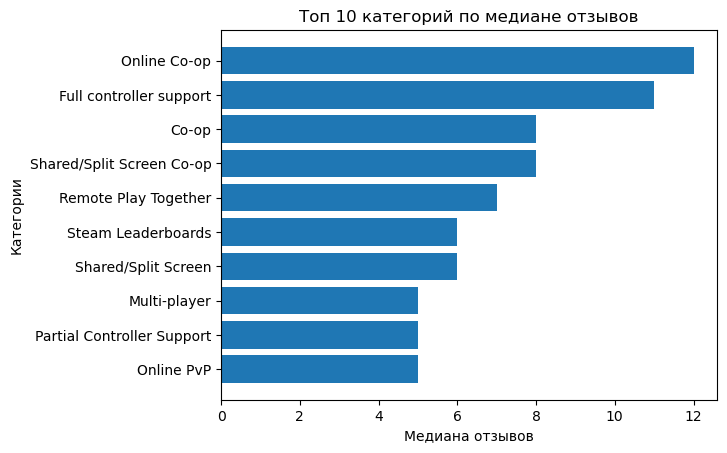

In [95]:
cat_reviews_data = []
for cat in top_cats:
    col = f"cat_{cat.lower().replace(' ','_').replace('/','_')}"
    reviews = df[df[col]==True]['total_reviews']
    if len(reviews) > 0:
        cat_reviews_data.append({'category': cat,'median_reviews': reviews.median(),'count': len(reviews)})
cat_reviews_df = pd.DataFrame(cat_reviews_data)
top_cats_median = cat_reviews_df.set_index('category')['median_reviews'].sort_values(ascending=False).head(10)

plt.barh(top_cats_median.index[::-1], top_cats_median.values[::-1])
plt.xlabel('Медиана отзывов')
plt.ylabel('Категории')
plt.title('Топ 10 категорий по медиане отзывов')
plt.show()

Самые успешные категории по числу отзывов - онлайн-кооператив, полная поддержка геймпада и кооператив (Online Co-op, Full controller support и Co-op)

### Распределение цены (price_usd)

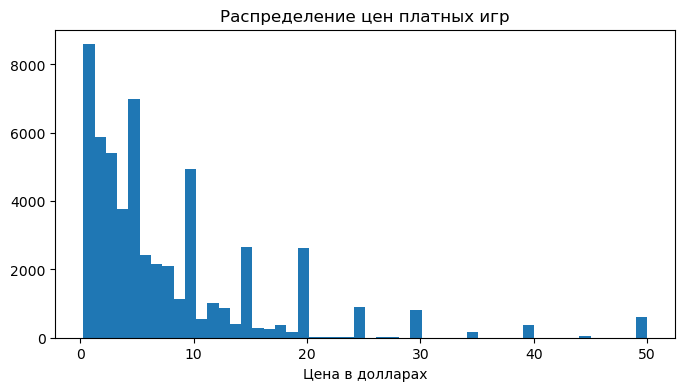

Статистика по ценам платных игр:
count    55611.000000
mean         8.346865
std         14.841521
min          0.270000
25%          1.990000
50%          4.990000
75%          9.990000
max       1000.000000
Name: price_usd, dtype: float64


In [96]:
paid = df.loc[df['price_usd'] > 0, 'price_usd']

plt.figure(figsize=(8, 4))
plt.hist(paid.clip(upper=paid.quantile(0.99)), bins=50)
plt.xlabel('Цена в долларах')
plt.title('Распределение цен платных игр')
plt.show()
print('Статистика по ценам платных игр:')
print(paid.describe())

Цены платных игр распределены неравномерно: основная масса проектов сосредоточена в нижнем и среднем ценовом диапазоне, а дорогих игр заметно меньше. По статистике видно, что типичная цена находится существенно ниже максимальных значений, поэтому рынок платных игр в выборке в основном представлен недорогими и среднеценовыми проектами

### Анализ зависимости price_usd и total_reviews

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


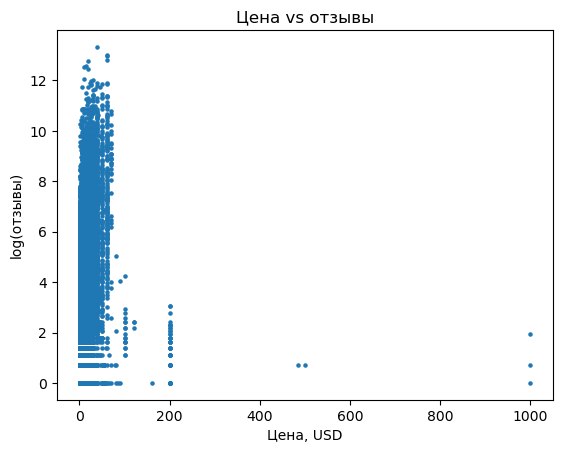

In [97]:
paid = df[df['price_usd'] > 0]

plt.scatter(paid['price_usd'], np.log(paid['total_reviews']), s=5)
plt.xlabel('Цена, USD')
plt.ylabel('log(отзывы)')
plt.title('Цена vs отзывы')
plt.show()

Судя по графику, тут прослеживается слабая негативная тенденция - чем дешевле игра, тем обычно больше отзывов. Наверное, это связано с тем, что низкая цена привлекает больше покупателей. Но при этом разброс значений огромный, и цена объясняет лишь малую часть вариации в отзывах

### Топ разработчиков по числу отзывов

In [98]:
dev = df[df['developers'].notna()][['developers', 'total_reviews']]
dev['developers'] = dev['developers'].str.split(' | ')
dev = dev.explode('developers')
cnt = dev['developers'].value_counts()
valid = cnt[cnt >= 5].index
top = dev[dev['developers'].isin(valid)].groupby('developers')['total_reviews'].median().sort_values(ascending=False).head(10)
print(top)

developers
Respawn         47844.0
Rockstar        20165.5
DICE            17359.5
World's         13399.0
Empires         13399.0
Montreal        12282.0
Nixxes          10419.0
BioWare          9669.0
Beenox           8673.0
Sledgehammer     8673.0
Name: total_reviews, dtype: float64


Respawn, Rockstar и DICE лидируют по медиане отзывов

### Топ издателей по числу отзывов

In [99]:
pub = df[df['publishers'].notna()][['publishers', 'total_reviews']]
pub['publishers'] = pub['publishers'].str.split(' | ')
pub = pub.explode('publishers')
cnt = pub['publishers'].value_counts()
valid = cnt[cnt >= 5].index
top = pub[pub['publishers'].isin(valid)].groupby('publishers')['total_reviews'].median().sort_values(ascending=False).head(10)
print(top)

publishers
PlayStation    12477.0
Warner         11128.0
Rockstar       10113.0
Xbox            8991.0
2K              7239.0
Activision      6809.5
Stain           5279.0
Bethesda        3775.0
Focus           3706.0
SEGA            3425.5
Name: total_reviews, dtype: float64


PlayStation, Warner и Rockstar лидируют по медиане отзывов

### Распределение возраста

In [101]:
def age_group(age):
    if age == 0:
        return 'Нет ограничений'
    elif age <= 12:
        return '6-12'
    elif age <= 16:
        return '13-16'
    else:
        return '17+'
df['age_group'] = df['required_age'].fillna(0).apply(age_group)
age_stats = df.groupby('age_group')['total_reviews'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False)
print(age_stats)

                 count  median         mean
age_group                                  
17+                584    20.0  5758.152397
13-16              697     7.0  1389.763271
6-12               585     4.0   231.635897
Нет ограничений  59325     4.0   276.859536


Видно, что игры с ограничением 17+ в среднем получают больше отзывов, чем с меньшими возрастными ограничениями. У этой группы самая высокая медиана и самое высокое среднее значение total_reviews. Категория 13–16 также выглядит лучше чем игры для более широкой аудитории. При этом надо учитывать, что основную часть датасета составляют игры без ограничений поэтому объемы сравниваемых групп сильно отличаются по кол-ву. Но тут видно, что именно игры с более высоким возрастным ограничением чаще связаны с более высоким пользовательским интересом

## Итоговые выводы

По итогам EDA можно сказать, что интерес аудитории к играм Steam распределён крайне неравномерно. Медиана total_reviews всего 4, среднее больше 340, а 75% игр имеют не более 20 отзывов. Большинство проектов получает очень мало внимания, а весь заметный интерес концентрируется у небольшой группы игр.

Среди числовых признаков сильнее всего с total_reviews связаны owners_upper (0.50) и player_count (0.45). Там где уже есть широкая аудитория и активный онлайн, отзывов тоже больше. playtime_median_min тоже даёт положительную связь, но слабую (0.10): сама по себе длительность игры популярность не объясняет.

По ценам: рынок платных игр сосредоточен в низком и среднем диапазоне. Зависимость между ценой и числом отзывов слабая и скорее отрицательная, то есть более дешёвые игры в среднем собирают чуть больше отзывов, но цена точно не главный фактор

Среди жанров по числу отзывов выделяются Simulation, RPG и Sports, среди категорий лидируют онлайн-кооператив, кооператив и полная поддержка геймпада. То есть игры с кооперативным форматом и хорошей поддержкой железа получают заметно больше внимания. По возрастному рейтингу игры с маркировкой 17+ показывают самую высокую медиану отзывов, хотя таких игр в выборке еньше.

Если резюмировать: компании при планировании релиза стоит смотреть на жанр (RPG, Simulation, Sports), закладывать кооперативный режим и поддержку геймпада, и не бояться более взрослой аудитории. Это не гарантия успеха, но именно эти признаки в нашей выборке чаще всего совпадают с играми, у которых много отзывов